<a href="https://colab.research.google.com/github/adeedamukhtar/Early-pneumonia-detection/blob/main/pneumonia_detection_Final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install and upload necessary Libraries


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tolgadincer/labeled-chest-xray-images")

print("Path to dataset files:", path)

100%|██████████| 1.17G/1.17G [00:41<00:00, 30.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tolgadincer/labeled-chest-xray-images/versions/1


# Download and setup the Dataset


In [ ]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/tolgadincer/labeled-chest-xray-images/versions/1"
print(os.listdir(dataset_path))


['chest_xray']


In [ ]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/tolgadincer/labeled-chest-xray-images/versions/1/chest_xray"
print(os.listdir(dataset_path))


['test', 'train']


In [ ]:
import os

train_dir = "/root/.cache/kagglehub/datasets/tolgadincer/labeled-chest-xray-images/versions/1/chest_xray/train"
test_dir = "/root/.cache/kagglehub/datasets/tolgadincer/labeled-chest-xray-images/versions/1/chest_xray/test"

print("Train classes:", os.listdir(train_dir))
print("Test classes:", os.listdir(test_dir))


Train classes: ['PNEUMONIA', 'NORMAL']
Test classes: ['PNEUMONIA', 'NORMAL']


# Create Validation set

In [ ]:
val_dir = "/root/.cache/kagglehub/datasets/tolgadincer/labeled-chest-xray-images/versions/1/chest_xray/val"

# Create new validation folders
os.makedirs(os.path.join(val_dir, "PNEUMONIA"), exist_ok=True)
os.makedirs(os.path.join(val_dir, "NORMAL"), exist_ok=True)


In [ ]:
import shutil
import random

# Function to move files
def split_data(source, destination, split_ratio=0.2):
    files = os.listdir(source)
    num_val = int(len(files) * split_ratio)
    val_files = random.sample(files, num_val)

    for file in val_files:
        shutil.move(os.path.join(source, file), os.path.join(destination, file))

# Move images
split_data(os.path.join(train_dir, "PNEUMONIA"), os.path.join(val_dir, "PNEUMONIA"))
split_data(os.path.join(train_dir, "NORMAL"), os.path.join(val_dir, "NORMAL"))

print("Validation set created successfully!")


Validation set created successfully!


# Load and Normalize the Dataset

In [ ]:
import tensorflow as tf

batch_size = 32
img_size = (150, 150)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, image_size=img_size, batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir, image_size=img_size, batch_size=batch_size
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir, image_size=img_size, batch_size=batch_size
)

# Print class names
print("Classes:", train_ds.class_names)


Found 4187 files belonging to 2 classes.
Found 1045 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Classes: ['NORMAL', 'PNEUMONIA']


In [ ]:
def normalize_ds(dataset):
    return dataset.map(lambda x, y: (x / 255.0, y))

train_ds = normalize_ds(train_ds)
val_ds = normalize_ds(val_ds)
test_ds = normalize_ds(test_ds)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Apply Data Augmentation

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))


# Define the CNN Model


In [ ]:
from tensorflow.keras import layers, models

# Define the CNN model
model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),  # Explicitly define input shape
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(2, activation='softmax')  # 2 classes: NORMAL & PNEUMONIA
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Display model summary
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      18,940,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │           1,026 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,034,690 (72.61 MB)

 Trainable params: 19,034,690 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

# Define dataset paths


In [ ]:
import os

# Define dataset paths
dataset_path = "/root/.cache/kagglehub/datasets/tolgadincer/labeled-chest-xray-images/versions/1/chest_xray"
train_dir = os.path.join(dataset_path, "train")
test_dir = os.path.join(dataset_path, "test")
val_dir = os.path.join(dataset_path, "val")  # If missing, we created it earlier

print("Train classes:", os.listdir(train_dir))
print("Test classes:", os.listdir(test_dir))
print("Validation classes:", os.listdir(val_dir))


Train classes: ['PNEUMONIA', 'NORMAL']
Test classes: ['PNEUMONIA', 'NORMAL']
Validation classes: ['PNEUMONIA', 'NORMAL']


# Preprocess the data

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

batch_size = 32
img_size = (150, 150)

train_ds = image_dataset_from_directory(train_dir, image_size=img_size, batch_size=batch_size)
val_ds = image_dataset_from_directory(val_dir, image_size=img_size, batch_size=batch_size)
test_ds = image_dataset_from_directory(test_dir, image_size=img_size, batch_size=batch_size)

class_names = train_ds.class_names
print("Classes:", class_names)


Found 4187 files belonging to 2 classes.
Found 1045 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Classes: ['NORMAL', 'PNEUMONIA']


In [ ]:
from tensorflow.keras import layers

# Normalize pixel values
def normalize_ds(dataset):
    return dataset.map(lambda x, y: (x / 255.0, y))

train_ds = normalize_ds(train_ds)
val_ds = normalize_ds(val_ds)
test_ds = normalize_ds(test_ds)

# Apply data augmentation only to training data
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))


# Train the model

In [ ]:
from tensorflow.keras import layers, models

# Define CNN model
model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(2, activation='softmax')  # Output for 2 classes
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(train_ds, validation_data=val_ds, epochs=10)


Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.7152 - loss: 0.6164 - val_accuracy: 0.8593 - val_loss: 0.3617
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 309s 2s/step - accuracy: 0.8521 - loss: 0.3431 - val_accuracy: 0.7866 - val_loss: 0.4238
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.8802 - loss: 0.2800 - val_accuracy: 0.8383 - val_loss: 0.3678
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 326s 2s/step - accuracy: 0.8945 - loss: 0.2535 - val_accuracy: 0.9167 - val_loss: 0.2049
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - accuracy: 0.8989 - loss: 0.2509 - val_accuracy: 0.9282 - val_loss: 0.1873
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 325s 2s/step - accuracy: 0.9110 - loss: 0.2195 - val_accuracy: 0.9368 - val_loss: 0.1703
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 382s 2s/step - accuracy: 0.9260 - loss: 0.1831 - val_accuracy: 0.8450 - val_loss: 0.3742
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 380s 2s/step - accuracy: 0.9338 - loss: 0.1755 - val_accu

#Setting path

In [ ]:
test_dir = 'path/to/your/test/dataset'


In [ ]:
test_dir = r'C:\Users\username\path\to\dataset\test'


In [ ]:
dataset_dir = '/root/.cache/kagglehub/datasets/tolgadincer/labeled-chest-xray-images/versions/1'

# Example of the test directory path
test_dir = os.path.join(dataset_dir, 'test')  # Update this path based on your actual dataset location


In [ ]:
import os

# Path to the dataset
dataset_dir = '/root/.cache/kagglehub/datasets/tolgadincer/labeled-chest-xray-images/versions/1'

# List the contents of the dataset directory
print("Dataset folder contents:", os.listdir(dataset_dir))


Dataset folder contents: ['chest_xray']


In [ ]:
# Check the contents of the 'chest_xray' folder
chest_xray_dir = os.path.join(dataset_dir, 'chest_xray')
print("Chest X-ray folder contents:", os.listdir(chest_xray_dir))


Chest X-ray folder contents: ['val', 'test', 'train']


In [ ]:
from tensorflow.keras.preprocessing import image_dataset_from_directory
import os

# Define the path to the dataset directory
dataset_dir = '/root/.cache/kagglehub/datasets/tolgadincer/labeled-chest-xray-images/versions/1/chest_xray'

# Define subdirectories for train, validation, and test
train_dir = os.path.join(dataset_dir, 'train')
val_dir = os.path.join(dataset_dir, 'val')
test_dir = os.path.join(dataset_dir, 'test')

# Load the datasets
train_dataset = image_dataset_from_directory(
    train_dir,
    image_size=(150, 150),  # Resize images to match the input size of the model
    batch_size=32,
    label_mode='int'  # Labels as integers
)

val_dataset = image_dataset_from_directory(
    val_dir,
    image_size=(150, 150),  # Resize images to match the input size of the model
    batch_size=32,
    label_mode='int'  # Labels as integers
)

test_dataset = image_dataset_from_directory(
    test_dir,
    image_size=(150, 150),  # Resize images to match the input size of the model
    batch_size=32,
    label_mode='int'  # Labels as integers
)

# Print the size of the datasets
print(f"Train dataset: {len(train_dataset)} batches")
print(f"Validation dataset: {len(val_dataset)} batches")
print(f"Test dataset: {len(test_dataset)} batches")


Found 4187 files belonging to 2 classes.
Found 1045 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Train dataset: 131 batches
Validation dataset: 33 batches
Test dataset: 20 batches


#Define Model Architecture


In [ ]:

import tensorflow as tf
from tensorflow.keras import layers, models

# Define the model architecture
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(150, 150, 3)),  # Rescale pixel values to [0, 1]
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(2, activation='softmax')  # 2 classes: Pneumonia and Normal
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',  # for integer labels
              metrics=['accuracy'])

# Train the model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


131/131 ━━━━━━━━━━━━━━━━━━━━ 251s 2s/step - accuracy: 0.7696 - loss: 0.6204 - val_accuracy: 0.9311 - val_loss: 0.1730
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - accuracy: 0.9437 - loss: 0.1559 - val_accuracy: 0.9617 - val_loss: 0.1148
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 284s 2s/step - accuracy: 0.9622 - loss: 0.0999 - val_accuracy: 0.9713 - val_loss: 0.0930
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.9675 - loss: 0.0775 - val_accuracy: 0.9684 - val_loss: 0.0994
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 314s 2s/step - accuracy: 0.9784 - loss: 0.0655 - val_accuracy: 0.9761 - val_loss: 0.0947
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - accuracy: 0.9794 - loss: 0.0562 - val_accuracy: 0.9742 - val_loss: 0.0971
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 323s 2s/step - accuracy: 0.9861 - loss: 0.0348 - val_accuracy: 0.9713 - val_loss: 0.0904
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.9874 - loss: 0.0353 - val_accuracy: 0.974

#Evaluate Model

In [ ]:
# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(test_dataset)

# Print the results
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")


20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 556ms/step - accuracy: 0.8728 - loss: 0.5998
Test Loss: 0.5839580297470093
Test Accuracy: 0.879807710647583


#Visualize Results


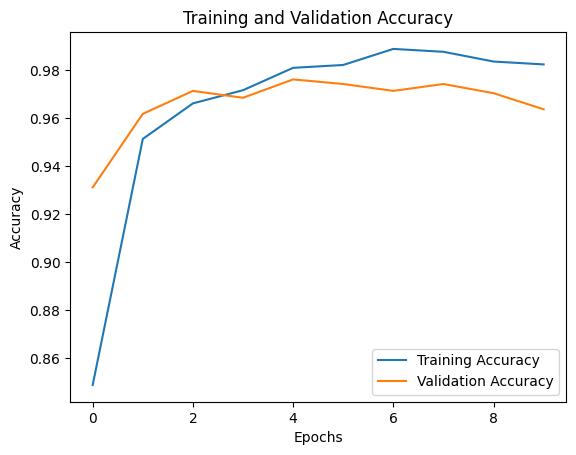

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()


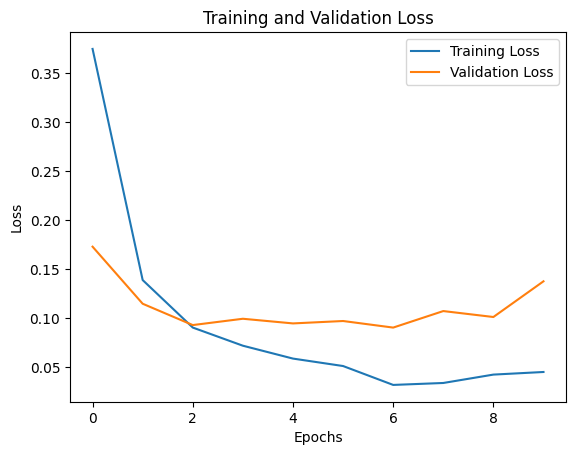

In [ ]:
# Plot training & validation loss values
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 788ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 556ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 569ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 527ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 629ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 597ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 653ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 887ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 826ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 877ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 515ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step


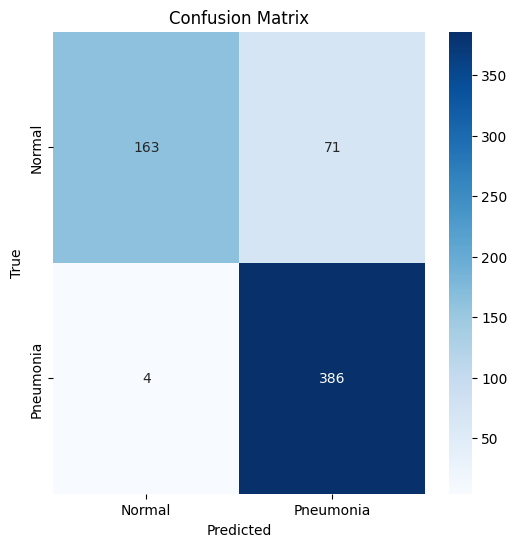

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Get predictions
y_true = []
y_pred = []

for images, labels in test_dataset:
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(model.predict(images), axis=1))

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 789ms/step


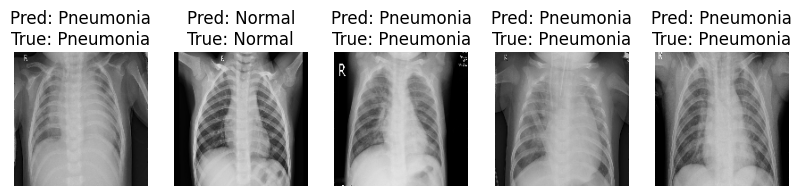

In [ ]:
import matplotlib.pyplot as plt

# Visualize a few test images and the model predictions
image_batch, label_batch = next(iter(test_dataset))

# Get predictions
predictions = model.predict(image_batch)

plt.figure(figsize=(10, 10))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))
    predicted_class = 'Pneumonia' if np.argmax(predictions[i]) == 1 else 'Normal'
    true_class = 'Pneumonia' if label_batch[i] == 1 else 'Normal'
    plt.title(f"Pred: {predicted_class}\nTrue: {true_class}")
    plt.axis('off')
plt.show()


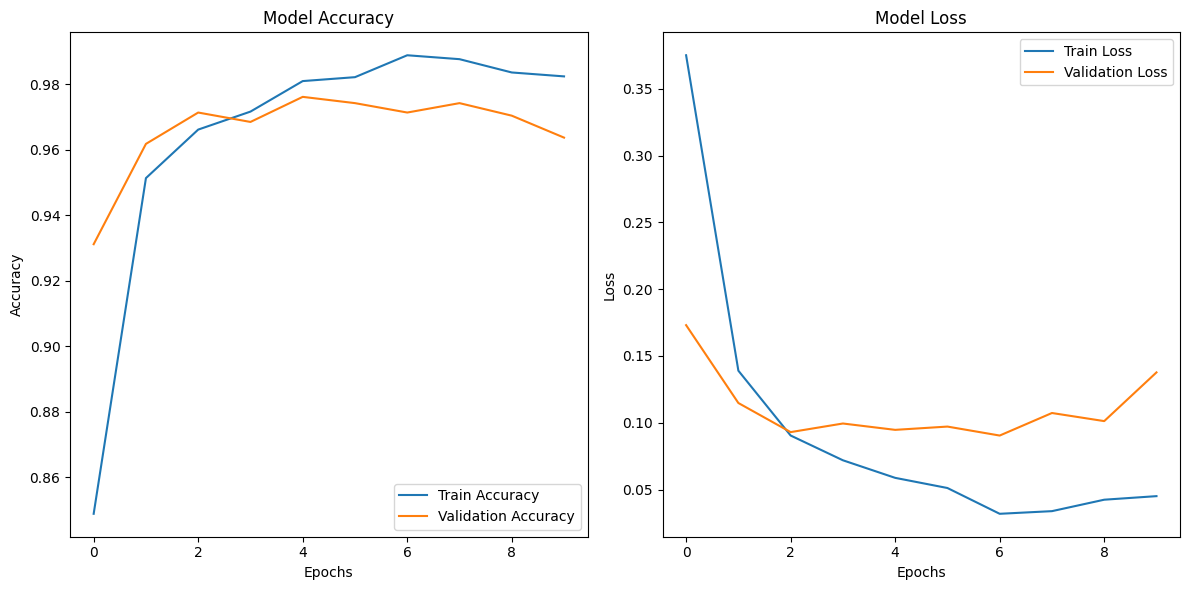

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 673ms/step


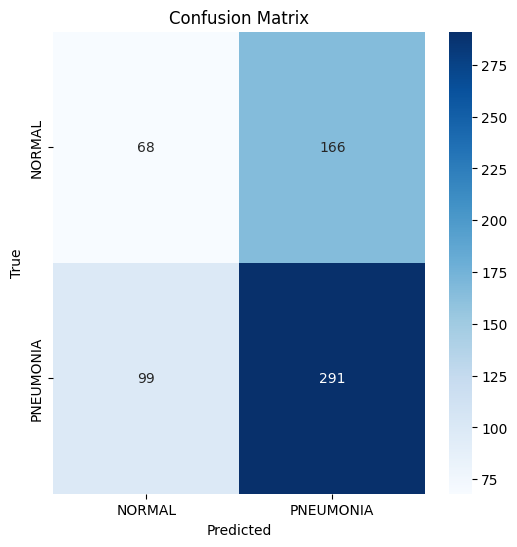

In [ ]:
import numpy as np

# Extract true labels from the test dataset
y_true = []
for images, labels in test_dataset:
    y_true.extend(labels.numpy())  # Get labels and add them to the list

y_true = np.array(y_true)

# Get the predicted labels
y_pred = model.predict(test_dataset)
y_pred_classes = np.argmax(y_pred, axis=1)  # Get the class with the highest probability

# Compute confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_dataset.class_names, yticklabels=test_dataset.class_names)
plt.title("Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 632ms/step


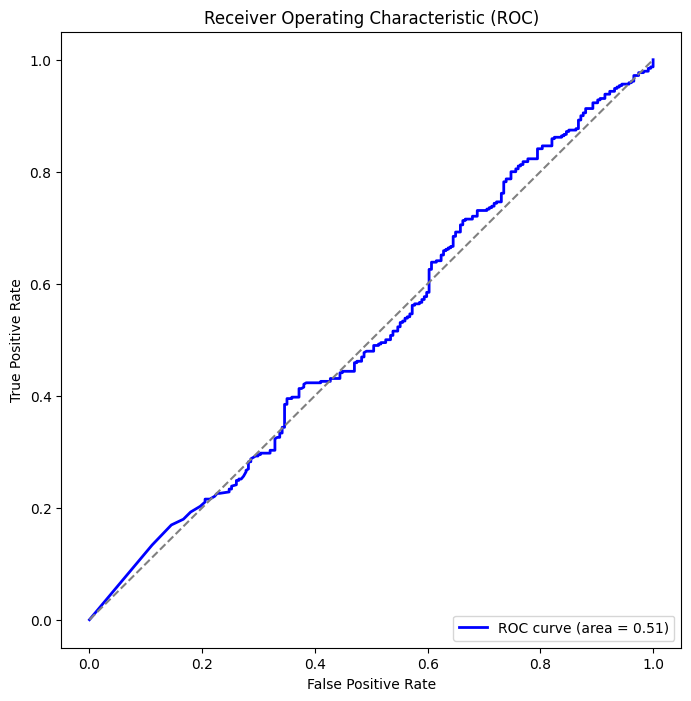

In [ ]:
from sklearn.metrics import roc_curve, auc

# Get model predictions for ROC curve
y_pred_prob = model.predict(test_dataset)

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_true, y_pred_prob[:, 1])
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8,8))
plt.plot(fpr, tpr, color='b', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


#Save the model

In [ ]:
import os

# List all files in the directory to check if the model exists
print(os.listdir())


['.config', 'drive', 'sample_data']


In [ ]:
model.save("pneumonia_detection_model.h5")  # Saves the trained model


In [ ]:
# prompt: save this model

# Ensure that 'model' is defined and compiled before saving
import tensorflow as tf
from tensorflow.keras import layers, models

# Define the model (or ensure previous cells with the model definition have been executed)
# prompt: save this model

# Ensure that 'model' is defined and compiled before saving
import tensorflow as tf
from tensorflow.keras import layers, models

# Define the model (or ensure previous cells with the model definition have been executed)
# Commented out the previous model definition
# model = models.Sequential([
#    layers.Input(shape=(150, 150, 3)),
#    layers.Conv2D(32, (3, 3), activation='relu')
#])

# Re-define the model as it was originally defined
model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(2, activation='softmax')  # Output for 2 classes
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Now you can save the model
model.save("pneumonia_detection_model.h5")  # Saves the trained model

In [ ]:
import tensorflow as tf

# Load the saved model using the correct filename
model = tf.keras.models.load_model("pneumonia_detection_model.h5")

# Manually compile the model with loss function and optimizer
model.compile(optimizer='adam',
              loss='binary_crossentropy',  # Use 'categorical_crossentropy' if you have more than 2 classes
              metrics=['accuracy'])

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
# Load the saved model using the correct filename
loaded_model = tf.keras.models.load_model('pneumonia_detection_model.keras')

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
# Assuming your model is saved as 'pneumonia_detection_model.keras'
loaded_model = tf.keras.models.load_model('pneumonia_detection_model.keras')

In [ ]:
# Save the model in the correct format
model.save('pneumonia_detection_model.keras')

# Load the saved model
loaded_model = tf.keras.models.load_model('pneumonia_detection_model.keras')

In [ ]:
model.save('/path/to/directory/pneumonia_detection_model.h5')


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define the model
model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),  # Input layer for images (150x150 pixels, 3 color channels)
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),  # Convolutional layer with ReLU activation
    layers.MaxPooling2D((2, 2)),  # Max pooling layer to reduce spatial dimensions
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),  # Another convolutional layer
    layers.MaxPooling2D((2, 2)),  # Another max pooling layer
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),  # Convolutional layer
    layers.MaxPooling2D((2, 2)),  # Max pooling layer
    layers.Flatten(),  # Flatten the output for the dense layers
    layers.Dense(128, activation='relu'),  # Fully connected dense layer
    layers.Dense(1, activation='sigmoid')  # Output layer (binary classification)
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',  # Loss function for binary classification
              metrics=['accuracy'])  # Accuracy as the evaluation metric

# Save the model to a .keras file (native Keras format)
model.save('pneumonia_detection_model.keras')

# Print confirmation message
print("Model saved successfully in .keras format.")


Model saved successfully in .keras format.


In [ ]:
loaded_model = tf.keras.models.load_model('pneumonia_detection_model.keras')


In [ ]:
# Save the model without specifying the save_format
model.save('pneumonia_detection_model.keras')

#Test Model


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing import image

# Load the uploaded image
img_path = list(uploaded.keys())[0]  # Get the uploaded file name
img = image.load_img(img_path, target_size=(150, 150))  # Resize to match model input size

# Convert image to array
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Expand dimensions for model input
img_array /= 255.0  # Normalize (same preprocessing as training)


Saving VIRUS-987036-0003.jpeg to VIRUS-987036-0003.jpeg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
🩺 Prediction: The X-ray is classified as **Pneumonia**


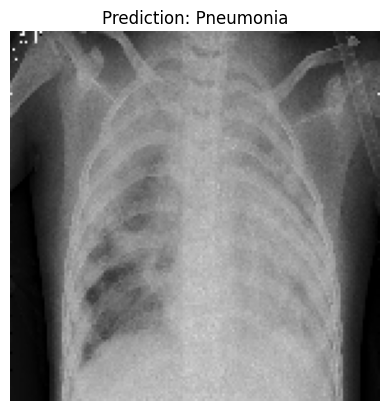

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from google.colab import files

# Upload an X-ray image
uploaded = files.upload()
img_path = list(uploaded.keys())[0]  # Get the uploaded filename

# Load and preprocess the image
img = image.load_img(img_path, target_size=(150, 150))  # Resize to match model input size
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Expand dimensions for model input
img_array /= 255.0  # Normalize (same as training preprocessing)

# Load the trained model
model = tf.keras.models.load_model('/content/pneumonia_detection_model.h5')

# Make a prediction
prediction = model.predict(img_array)

# Class labels
class_labels = ["Normal", "Pneumonia"]

# Get predicted class (0 for Normal, 1 for Pneumonia)
predicted_class = class_labels[int(prediction[0][0] > 0.5)]

# Display the result
print(f"🩺 Prediction: The X-ray is classified as **{predicted_class}**")

# Show the image with prediction
plt.imshow(img)
plt.axis('off')
plt.title(f"Prediction: {predicted_class}")
plt.show()
